# Table 1 — crystal ligand structures

The crystal ligand of each of the 11 benchmark targets, rendered with the same 2D depiction
settings as the app (white background). Saved to `notebooks/ligands-figure.png`.

In [1]:
%matplotlib inline
import io, json, math
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from PIL import Image
from rdkit import Chem
from rdkit.Chem import rdCoordGen, rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

ROOT = Path.cwd()
for _ in range(4):
    if (ROOT / 'benchmarks').is_dir():
        break
    ROOT = ROOT.parent

# 10 DUD-Z targets from the manifest, in the benchmark's order, plus abl1 (dev target).
man = {json.loads(l)['target']: json.loads(l)['smiles']
       for l in open(ROOT / 'benchmarks/data/manifest.jsonl')}
ABL1 = 'Cc1cc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)ccc1F'
ORDER = ['EGFR', 'AA2AR', 'ANDR', 'HIVPR', 'FA10', 'HDAC8', 'PARP1', 'HS90A', 'ADA', 'NRAM', 'ABL1']
smiles = {**man, 'ABL1': ABL1}
print(len(ORDER), 'ligands')

11 ligands


saved /home/ben/packages/chemistree/notebooks/ligands-figure.png | 11.8 x 10.2 in


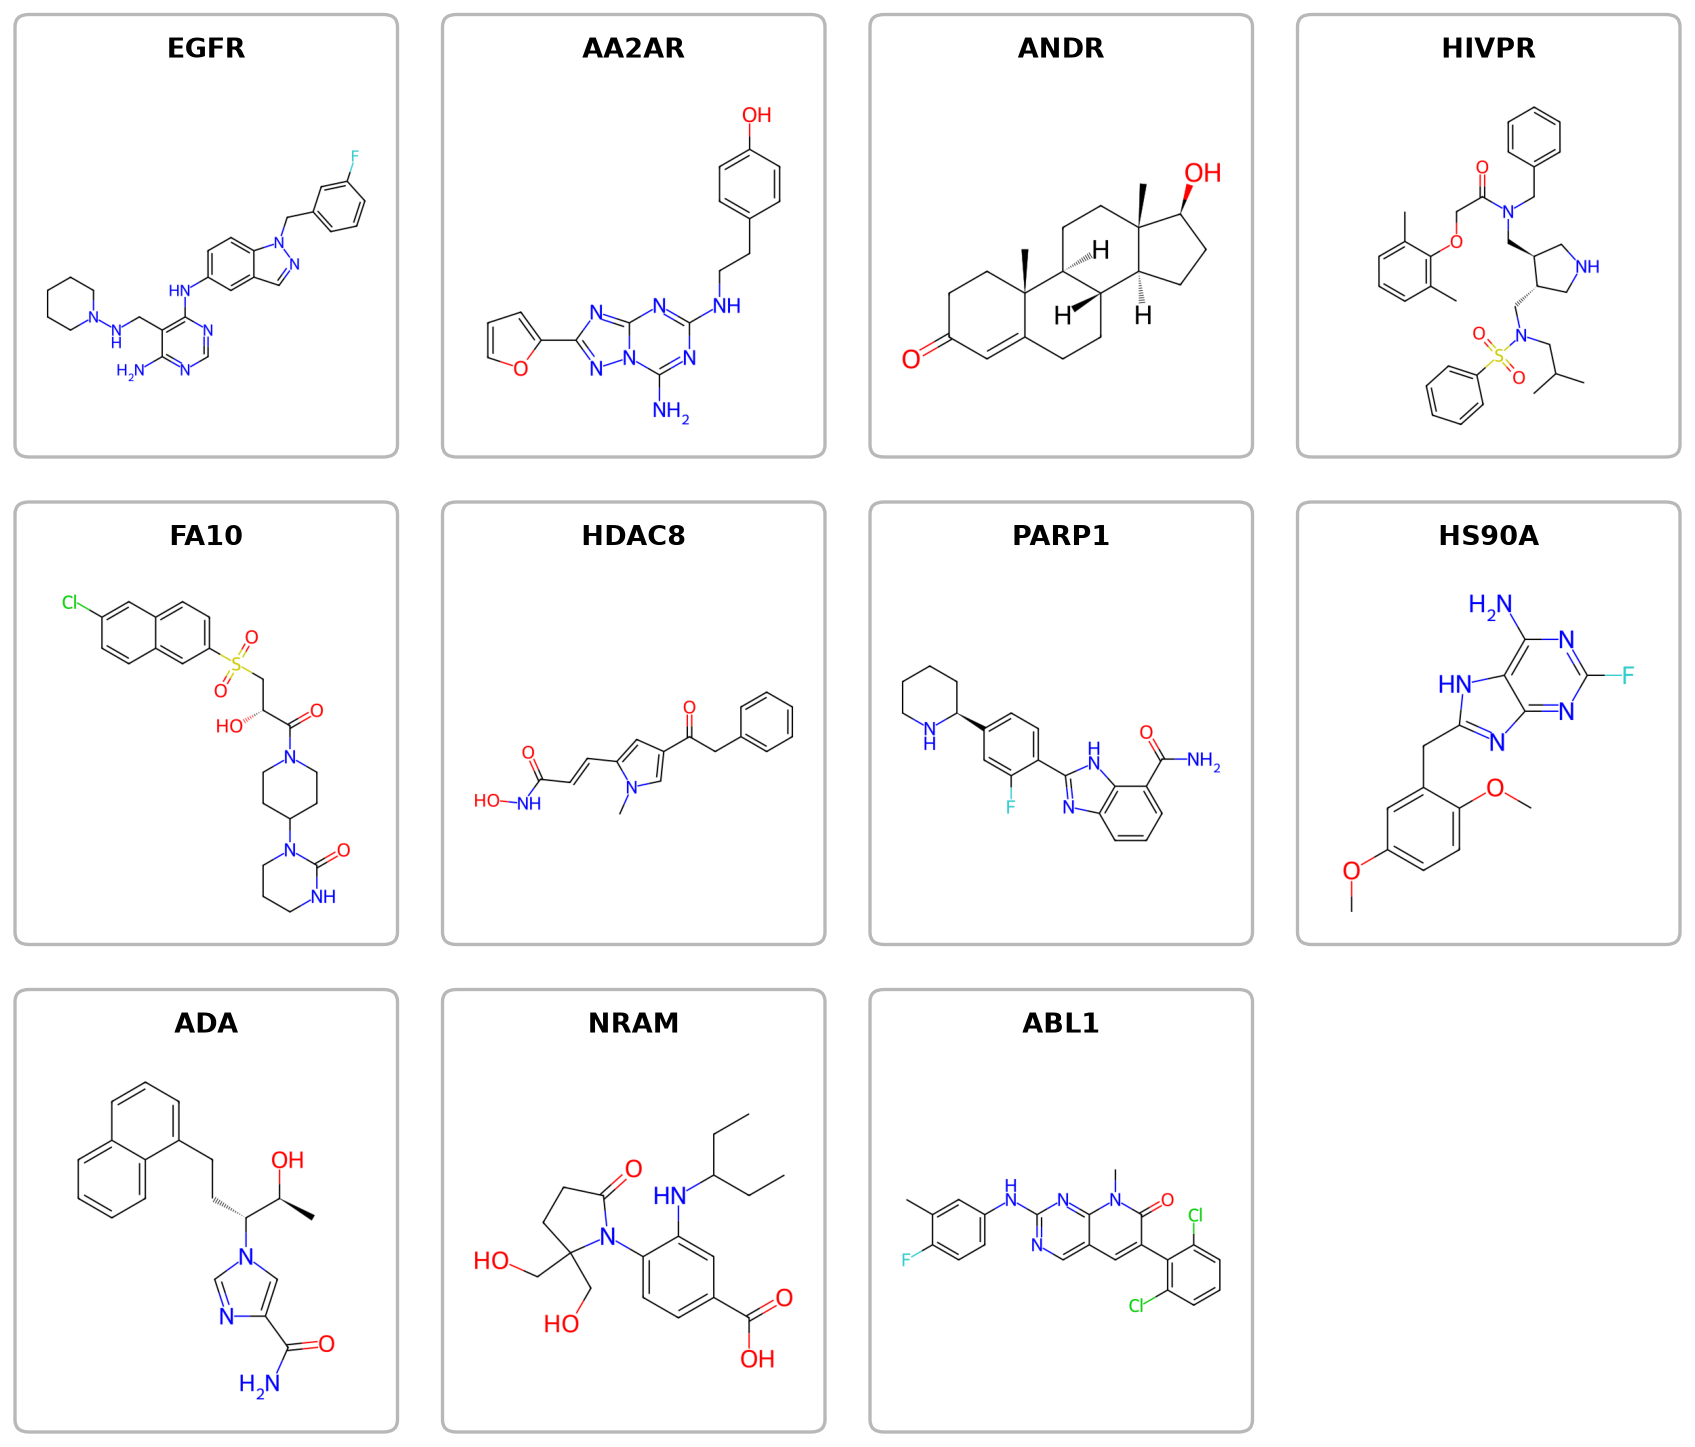

In [2]:
def render(smi, px=520):
    """White-background 2D depiction with the app's coordinate settings (render.py)."""
    m = Chem.MolFromSmiles(smi)
    rdCoordGen.AddCoords(m)
    rdDepictor.StraightenDepiction(m)
    d = rdMolDraw2D.MolDraw2DCairo(px, px)
    d.drawOptions().clearBackground = True
    d.DrawMolecule(m)
    d.FinishDrawing()
    return Image.open(io.BytesIO(d.GetDrawingText()))

# ---- grid layout (inches) ----
COLS = 4
ROWS = math.ceil(len(ORDER) / COLS)
STRUCT, TITLE_H, PAD, GAP, MARG = 2.35, 0.40, 0.10, 0.30, 0.35
CELL = STRUCT + 2 * PAD
EDGE = '#b8b8b8'

figW = MARG * 2 + COLS * CELL + (COLS - 1) * GAP
figH = MARG * 2 + ROWS * (CELL + TITLE_H) + (ROWS - 1) * GAP
fig = plt.figure(figsize=(figW, figH), dpi=150)
fig.patch.set_facecolor('white')
fx, fy = 1.0 / figW, 1.0 / figH

for i, t in enumerate(ORDER):
    r, c = divmod(i, COLS)
    x = MARG + c * (CELL + GAP)
    top = MARG + r * (CELL + TITLE_H + GAP)
    # rounded cell border around title + structure
    ch = CELL + TITLE_H
    fig.add_artist(FancyBboxPatch((x * fx, (figH - top - ch) * fy), CELL * fx, ch * fy,
                   boxstyle='round,pad=0,rounding_size=0.008', linewidth=1.6,
                   edgecolor=EDGE, facecolor='white', transform=fig.transFigure, zorder=1))
    # target name (bold title)
    fig.text((x + CELL / 2) * fx, (figH - (top + TITLE_H * 0.60)) * fy, t,
             ha='center', va='center', fontsize=13, fontweight='bold', zorder=3)
    # structure
    sb = top + TITLE_H + PAD
    ax = fig.add_axes([(x + PAD) * fx, (figH - sb - STRUCT) * fy, STRUCT * fx, STRUCT * fy], zorder=2)
    ax.imshow(render(smiles[t])); ax.axis('off')

OUT = ROOT / 'notebooks'
fig.savefig(OUT / 'ligands-figure.png', dpi=150, facecolor='white')
print('saved', OUT / 'ligands-figure.png', '|', round(figW, 1), 'x', round(figH, 1), 'in')
plt.show()